In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import importlib
import numpy as np

godfather_dir = '/Users/sloenen/Documents/00_Github_code/00_Delft_Networks/03_tidy3d_simulations'
if godfather_dir not in sys.path:
    sys.path.append(godfather_dir) 

NanobeamSimLib = importlib.import_module('01_scripts.NanobeamSimLib'); importlib.reload(NanobeamSimLib)


import tidy3d as td
import matplotlib.pyplot as plt
import tidy3d.web as web

## Initializing the simulation

In [2]:
sim = NanobeamSim(
    GeneralSimParams(
        size_x = 9.0,
        size_y = 2.0,
        size_z = 2.0,
        wavelength = 0.619,
        symmetry = (0, 0, 0),
        mesh_per_wvl = 14,
    )
)

NameError: name 'NanobeamSim' is not defined

## Adding all diamond structures

In [23]:
# Waveguide 1
params = WaveguideParams(
    beam_size_x = td.inf,
    beam_size_y = 0.250,
    beam_size_z=0.180,
    beam_loc_y = 0,
)
sim.add_waveguide_nanobeam(params)

In [24]:
# Support 1
params = WaveguideParams(
    beam_size_x = 0.200,
    beam_size_y = td.inf,
    beam_loc_x=0,
    beam_size_z=0.180,
)
sim.add_waveguide_nanobeam(params)

## Adding the mode source

In [5]:
# # input mode source
# params = ModeSourceParams(
#     mode_loc_x = - 4,
#     mode_loc_y = 0,
#     mode_size_y = 0.500,
#     mode_size_z = 0.500,
#     mode_name = "mode_source",
#     mode_index = 1,
# )
# sim.add_mode_source(params)

In [25]:
# adding dipole source
params = DipoleParams(
    dipole = 'trans',
    dip_loc_x = - 4.0,
    dip_loc_y = -0,
    dip_loc_z=0.180/2 - 0.070,
)
sim.add_dipole_source(params)

## Adding the monitors

In [26]:
# Adding a steady state field monitor
params = MonitorParams(
    mon_size_x = 8,
    mon_size_y = 1,
    mon_size_z = 1,
    mon_name = "field_mon"
)
sim.add_field_monitor(params)

In [27]:
# Adding a first mode monitor
params = MonitorParams(
    mon_loc_x = 4,
    mon_loc_y = 0,
    mon_size_y = 0.500,
    mon_size_z = 0.500,
    mon_name = "mode_mon_1"
)
sim.add_mode_monitor(params)

In [28]:
# Adding a second mode monitor
params = MonitorParams(
    mon_loc_x = -2,
    mon_loc_y = 0,
    mon_size_y = 0.500,
    mon_size_z = 0.500,
    mon_name = "mode_mon_2"
)
sim.add_mode_monitor(params)

## Generating the simulation object and plotting the simulation

Structure types: [<class 'tidy3d.components.structure.Structure'>, <class 'tidy3d.components.structure.Structure'>]
Source types: [<class 'tidy3d.components.source.current.PointDipole'>, <class 'tidy3d.components.source.current.PointDipole'>]
Monitor types: [<class 'tidy3d.components.monitor.FieldMonitor'>, <class 'tidy3d.components.monitor.ModeMonitor'>, <class 'tidy3d.components.monitor.ModeMonitor'>]


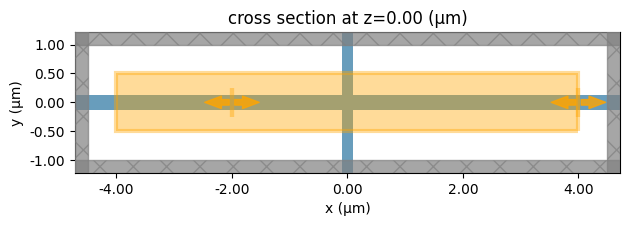

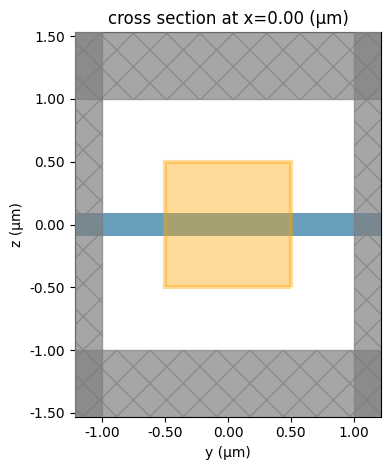

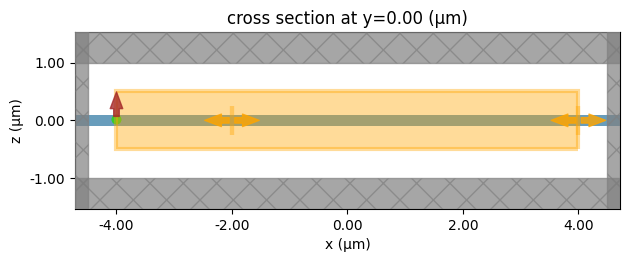

In [29]:
sim.generate_sim_object()
sim.plot_sim()

## Running the simulation

In [30]:
run_id = web.upload(sim.sim, task_name="test")
web.start(run_id)
web.monitor(run_id)
data = web.load(run_id)

15:52:12 CEST Created task 'test' with task_id                                  
              'fdve-0bbf4e29-e8c7-40d0-9591-772086af6520' and task_type 'FDTD'.

              View task using web UI at                                         
              ]8;id=627201;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=632318;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\taskId]8;;\]8;id=627201;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\=]8;;\]8;id=632544;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\fdve]8;;\]8;id=627201;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\-0bbf4e29-e8]8;;\
              ]8;id=627201;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\c7-40d0-9591-772086af6520']8;;\.

              Task folder: ]8;id=647482;https://tidy3d.simulation.cloud/folders/folder-51e1df5c-ad42-49f7-8cac-df6896fd5af8\'default']8;;\.

Output()

15:52:14 CEST Maximum FlexCredit cost: 0.028. Minimum cost depends on task      
              execution details. Use 'web.real_cost(task_id)' to get the billed 
              FlexCredit cost after a simulation run.

...

Output()

15:52:30 CEST status = success

15:52:32 CEST View simulation result at                                         
              ]8;id=230469;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=946704;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\taskId]8;;\]8;id=230469;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\=]8;;\]8;id=205425;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\fdve]8;;\]8;id=230469;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\-0bbf4e29-e8]8;;\
              ]8;id=230469;https://tidy3d.simulation.cloud/workbench?taskId=fdve-0bbf4e29-e8c7-40d0-9591-772086af6520\c7-40d0-9591-772086af6520']8;;\.

Output()

15:52:40 CEST loading simulation from simulation_data.hdf5

## Some brief analysis

In [31]:
mode_data = data["mode_mon_1"]
amps = np.abs(mode_data.amps)
print(amps.sel(mode_index = 0))
print(amps.sel(mode_index = 1))

<xarray.DataArray (direction: 2, f: 1)> Size: 16B
array([[3.71613965e+01],
       [1.39666901e-02]])
Coordinates:
  * direction   (direction) <U1 8B '+' '-'
  * f           (f) float64 8B 4.843e+14
    mode_index  int64 8B 0
Attributes:
    units:      sqrt(W)
    long_name:  mode amplitudes
<xarray.DataArray (direction: 2, f: 1)> Size: 16B
array([[24.66757038],
       [ 0.02565691]])
Coordinates:
  * direction   (direction) <U1 8B '+' '-'
  * f           (f) float64 8B 4.843e+14
    mode_index  int64 8B 1
Attributes:
    units:      sqrt(W)
    long_name:  mode amplitudes


In [11]:
mode_data = data["mode_mon_2"]
amps = np.abs(mode_data.amps)
print(amps.sel(mode_index = 0))
print(amps.sel(mode_index = 1))

NameError: name 'data' is not defined

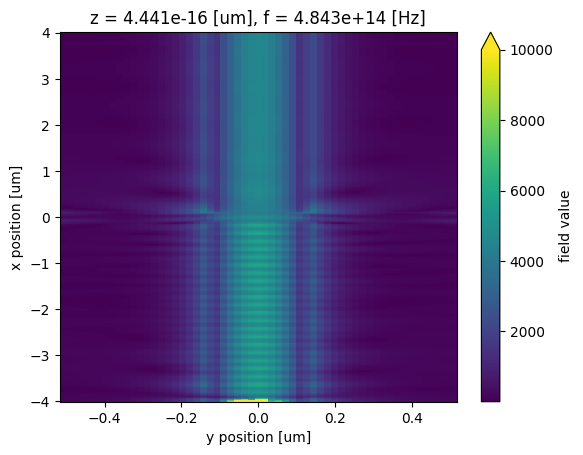

In [33]:
field_data = data["field_mon"]
Ex = field_data.field_components['Ey']
Ex.sel(z=0, method='nearest').abs.plot(vmax=10000)
plt.show()

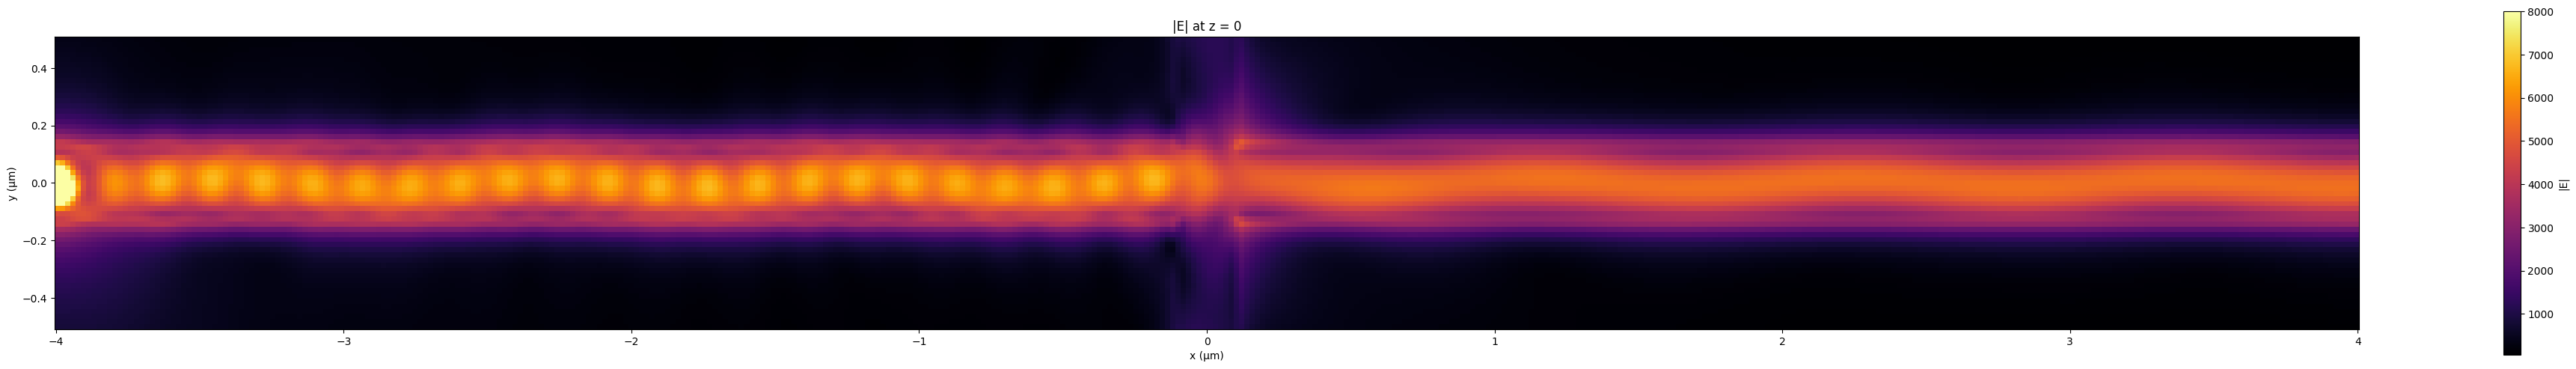

In [32]:
import numpy as np
import matplotlib.pyplot as plt

field_data = data["field_mon"]

# Get field components
Ex = field_data.field_components['Ex']
Ey = field_data.field_components['Ey']
Ez = field_data.field_components['Ez']

# Extract 2D slice at z = 0 and last time, then squeeze to 2D
Ex_2d = Ex.sel(z=0, method='nearest').squeeze()
Ey_2d = Ey.sel(z=0, method='nearest').squeeze()
Ez_2d = Ez.sel(z=0, method='nearest').squeeze()

# Compute field magnitude
E_mag = np.sqrt(np.abs(Ex_2d)**2 + np.abs(Ey_2d)**2 + np.abs(Ez_2d)**2)

# Coordinates
x = Ex_2d.coords['x'].values
y = Ex_2d.coords['y'].values
extent = [x.min(), x.max(), y.min(), y.max()]

# Calculate figure size proportional to physical size
x_span = x.max() - x.min()
y_span = y.max() - y.min()
aspect_ratio = x_span / y_span
fig_height = 5
fig_width = fig_height * aspect_ratio

# Plot
plt.figure(figsize=(fig_width, fig_height))
plt.imshow(E_mag.T, origin='lower', extent=extent, cmap='inferno', aspect='equal', vmax=8000)
plt.xlabel('x (μm)')
plt.ylabel('y (μm)')
plt.title('|E| at z = 0')
plt.colorbar(label='|E|')
plt.tight_layout()
plt.show()
